In [ ]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

print("Loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Loaded!
X shape: (70000, 784)
y shape: (70000,)


In [2]:
import numpy as np

X = X.astype("float32")
y = y.astype("int64")
X = X / 255.0

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

X dtype: float32
y dtype: int64
Min pixel value: 0.0
Max pixel value: 1.0


Shape before reshape: (784,)
Shape after reshape: (28, 28)


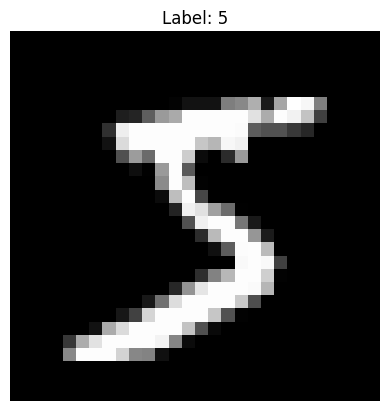

In [ ]:
import matplotlib.pyplot as plt

img = X[0]

print("Shape before reshape:", img.shape)

img_2d = img.reshape(28, 28)

print("Shape after reshape:", img_2d.shape)

plt.imshow(img_2d, cmap="gray")
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (56000, 784)
X_test: (14000, 784)
y_train: (56000,)
y_test: (14000,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 32

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(128, activation="relu")(encoder_input)
x = layers.Dense(64, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu")(x)

encoder = Model(encoder_input, latent, name="encoder")

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(64, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)
decoder_output = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(decoder_input, decoder_output, name="decoder")

# Autoencoder
autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
reconstructed = decoder(encoded)

autoencoder = Model(autoencoder_input, reconstructed, name="autoencoder")

# Show model summary
encoder.summary()
decoder.summary()
autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("Model Compiled Successfully")

Model compiled successfully!


In [7]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2588 - val_loss: 0.1758
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1553 - val_loss: 0.1413
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1354 - val_loss: 0.1297
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1266 - val_loss: 0.1223
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1193 - val_loss: 0.1161
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1141 - val_loss: 0.1123
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1101 - val_loss: 0.1083
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1071 - val_loss: 0.1058
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1045 - val_loss: 0.1040
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1026 - val_loss: 0.1017


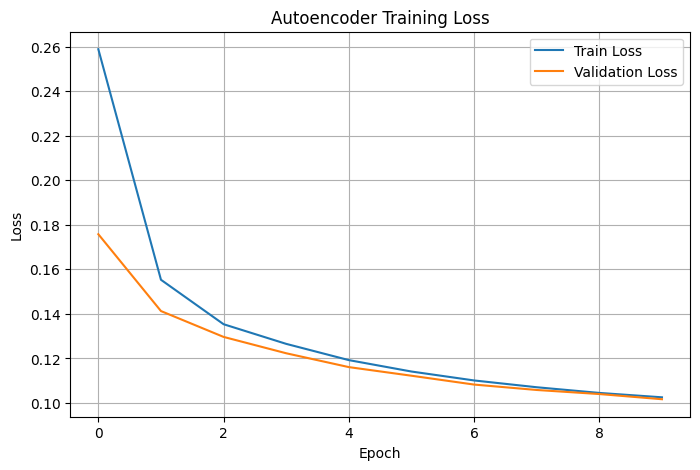

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step


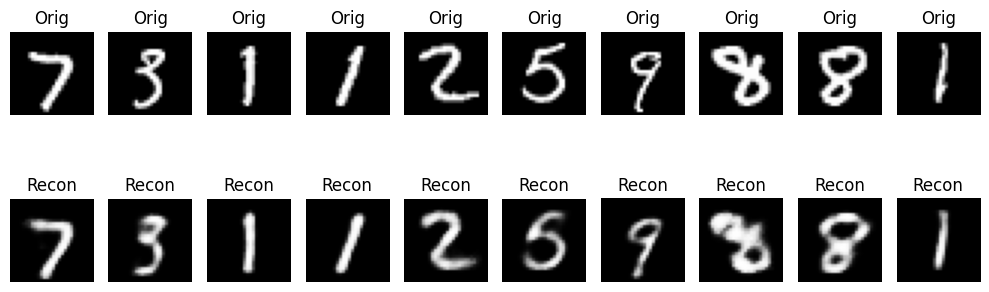

In [9]:
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(X_test[:10])
plt.figure(figsize=(10, 4))

# Original imag
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title("Orig")
    plt.axis("off")

for i in range(10):
    plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
encoded_train = encoder.predict(X_train)
encoded_test = encoder.predict(X_test)

print("Encoded train shape:", encoded_train.shape)
print("Encoded test shape:", encoded_test.shape)

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded train shape: (56000, 32)
Encoded test shape: (14000, 32)


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
encoded_2d = pca.fit_transform(encoded_test)

print("Encoded 2D shape:", encoded_2d.shape)

Encoded 2D shape: (14000, 2)


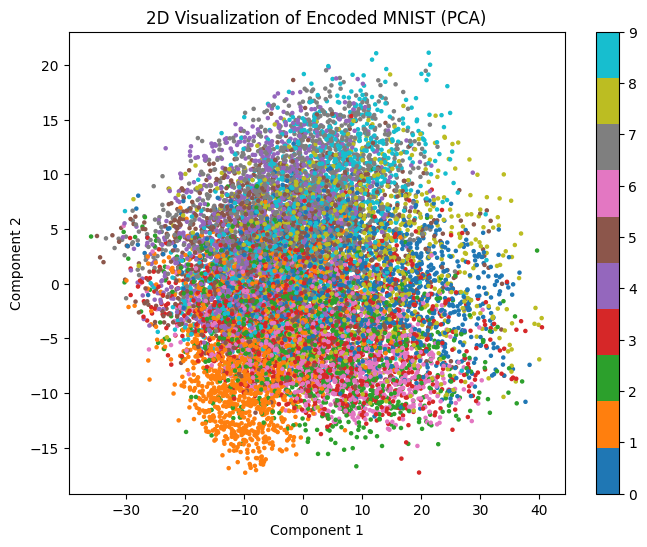

In [12]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    encoded_2d[:, 0],
    encoded_2d[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)
plt.title("2D Visualization of Encoded MNIST (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

query_index = 0


query_vector = encoded_test[query_index].reshape(1, -1)
similarities = cosine_similarity(query_vector, encoded_test)
similar_indices = similarities[0].argsort()[::-1][1:6]

print("Query index:", query_index)
print("Most similar indices:", similar_indices)

Query index: 0
Most similar indices: [ 3322 11503  1065  1268  3277]


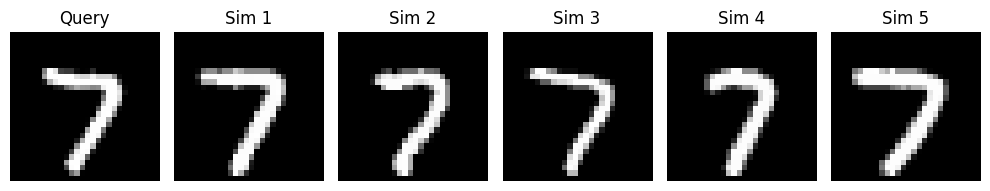

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

plt.subplot(1, 6, 1)
plt.imshow(X_test[query_index].reshape(28, 28), cmap="gray")
plt.title("Query")
plt.axis("off")

for i, idx in enumerate(similar_indices):
    plt.subplot(1, 6, i + 2)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Sim {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()